# AOP 2 - Data Mining

### Aluno: Lucas Delgado Leite

In [0]:
# Importando as bibliotecas
%pip install nbconvert
!pip install nltk -q
!pip install wordcloud -q
from pyspark.sql.functions import col, regexp_replace, trim, lower, split, explode, desc
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/spark-36da8b18-0a1c-4bd0-855a-fd/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [0]:
%fs
ls "dbfs:/databricks-datasets/cs100/lab1/data-001/shakespeare.txt"

path,name,size,modificationTime
dbfs:/databricks-datasets/cs100/lab1/data-001/shakespeare.txt,shakespeare.txt,5327978,1596560265000


In [0]:
# Definindo os dados
dados = '/databricks-datasets/cs100/lab1/data-001/shakespeare.txt'

In [0]:
# Definindo e lendo o nosso dataframe
df = spark.read.text(dados)
df.show(20, truncate=False)
print(df.count())

+-------------------------------------------------------+
|value                                                  |
+-------------------------------------------------------+
|1609                                                   |
|                                                       |
|THE SONNETS                                            |
|                                                       |
|by William Shakespeare                                 |
|                                                       |
|                                                       |
|                                                       |
|                     1                                 |
|  From fairest creatures we desire increase,           |
|  That thereby beauty's rose might never die,          |
|  But as the riper should by time decease,             |
|  His tender heir might bear his memory:               |
|  But thou contracted to thine own bright eyes,        |
|  Feed'st thy

In [0]:

# Filtrando a frase by William Shakespeare
coluna = col("value")
frase_filtro = "by William Shakespeare"

# Remover a frase
sem_frase = regexp_replace(coluna, frase_filtro, "")

# Remover caracteres especiais
sem_especiais = regexp_replace(sem_frase, r'[^a-zA-Z0-9\s]', '')

# Converte para minúsculas e remove espaços extras
limpo = trim(lower(sem_especiais))

# Removendo linhas com apenas números
df_limpo = df.withColumn("value", limpo).filter(~col("value").rlike(r"^\d+$"))

# Exibe as linhas para ver a diferença da limpeza
df_limpo.show(20, truncate=False)
print(f"Total de linhas após limpeza: {df_limpo.count()}")


+-------------------------------------------------+
|value                                            |
+-------------------------------------------------+
|                                                 |
|the sonnets                                      |
|                                                 |
|                                                 |
|                                                 |
|                                                 |
|                                                 |
|from fairest creatures we desire increase        |
|that thereby beautys rose might never die        |
|but as the riper should by time decease          |
|his tender heir might bear his memory            |
|but thou contracted to thine own bright eyes     |
|feedst thy lights flame with selfsubstantial fuel|
|making a famine where abundance lies             |
|thy self thy foe to thy sweet self too cruel     |
|thou that art now the worlds fresh ornament      |
|and only he

In [0]:
# Dividir as frases em palavras
shakeWordsDF = (df_limpo
                .select(explode(split(df_limpo.value, ' ')).alias('word'))
                .where("word != ''")
                )

# Exibe a palavra e a contagem
shakeWordsDFCount = shakeWordsDF.count()
topWordsAndCountsDF = shakeWordsDF.groupBy(shakeWordsDF.word).count().orderBy("count", ascending = False)
topWordsAndCountsDF.show()

# Exibe o total de palavras
print(shakeWordsDFCount)

+----+-----+
|word|count|
+----+-----+
| the|27361|
| and|26028|
|   i|20681|
|  to|19150|
|  of|17463|
|   a|14593|
| you|13615|
|  my|12481|
|  in|10956|
|that|10890|
|  is| 9134|
| not| 8497|
|with| 7771|
|  me| 7769|
|  it| 7678|
| for| 7558|
|  be| 6857|
| his| 6857|
|your| 6655|
|this| 6602|
+----+-----+
only showing top 20 rows
882690


In [0]:
# Stop Words padrão do NLTK
stop_words_default = set(stopwords.words('english'))

# Lista de palavras arcaicas que são equivalente a stop words modernas
custom_stopwords = {'thou', 'thee', 'thy', 'hath', 'thine', 'ye', 'art', 'dost', 'doth', 'hast', 'hath',
    'hadst', 'wilt', 'shouldst', 'wouldst', 'canst','ere', 'nay','tis', 'twas'}

# Unindo stop words padrão com as personalizadas
extended_stopwords = stop_words_default.union(custom_stopwords)

# Remover stopwords
sem_stop = shakeWordsDF.where(~shakeWordsDF.word.isin(extended_stopwords))

# Agrupa as palavras, a contagem e exibe
sem_stop.groupBy(sem_stop.word).count().orderBy("count", ascending = False).show()

# Exibe o total de palavras sem as stop words
print(sem_stop.count())

+-----+-----+
| word|count|
+-----+-----+
|shall| 3591|
| lord| 3059|
| king| 2861|
| good| 2812|
|  sir| 2754|
| come| 2507|
| well| 2462|
|would| 2293|
|  let| 2099|
|enter| 2098|
| love| 2053|
|  ill| 1972|
|  man| 1835|
|  one| 1779|
|   go| 1733|
| upon| 1731|
| like| 1701|
|  say| 1680|
| know| 1647|
|  may| 1633|
+-----+-----+
only showing top 20 rows
449864


In [0]:
# Criando uma lista para fazer o dicionário
dict_list = sem_stop.groupBy("word").count().orderBy("count", ascending=False).collect()

# Criando o dicionário de palavras e contagem
dict_freq = {row.word: row["count"] for row in dict_list}

# Imprimindo o dicionário
print(list(dict_freq.items())[:30])

[('shall', 3591), ('lord', 3059), ('king', 2861), ('good', 2812), ('sir', 2754), ('come', 2507), ('well', 2462), ('would', 2293), ('let', 2099), ('enter', 2098), ('love', 2053), ('ill', 1972), ('man', 1835), ('one', 1779), ('go', 1733), ('upon', 1731), ('like', 1701), ('say', 1680), ('know', 1647), ('may', 1633), ('make', 1629), ('us', 1621), ('yet', 1569), ('must', 1491), ('see', 1438), ('give', 1327), ('take', 1197), ('speak', 1165), ('mine', 1161), ('first', 1159)]


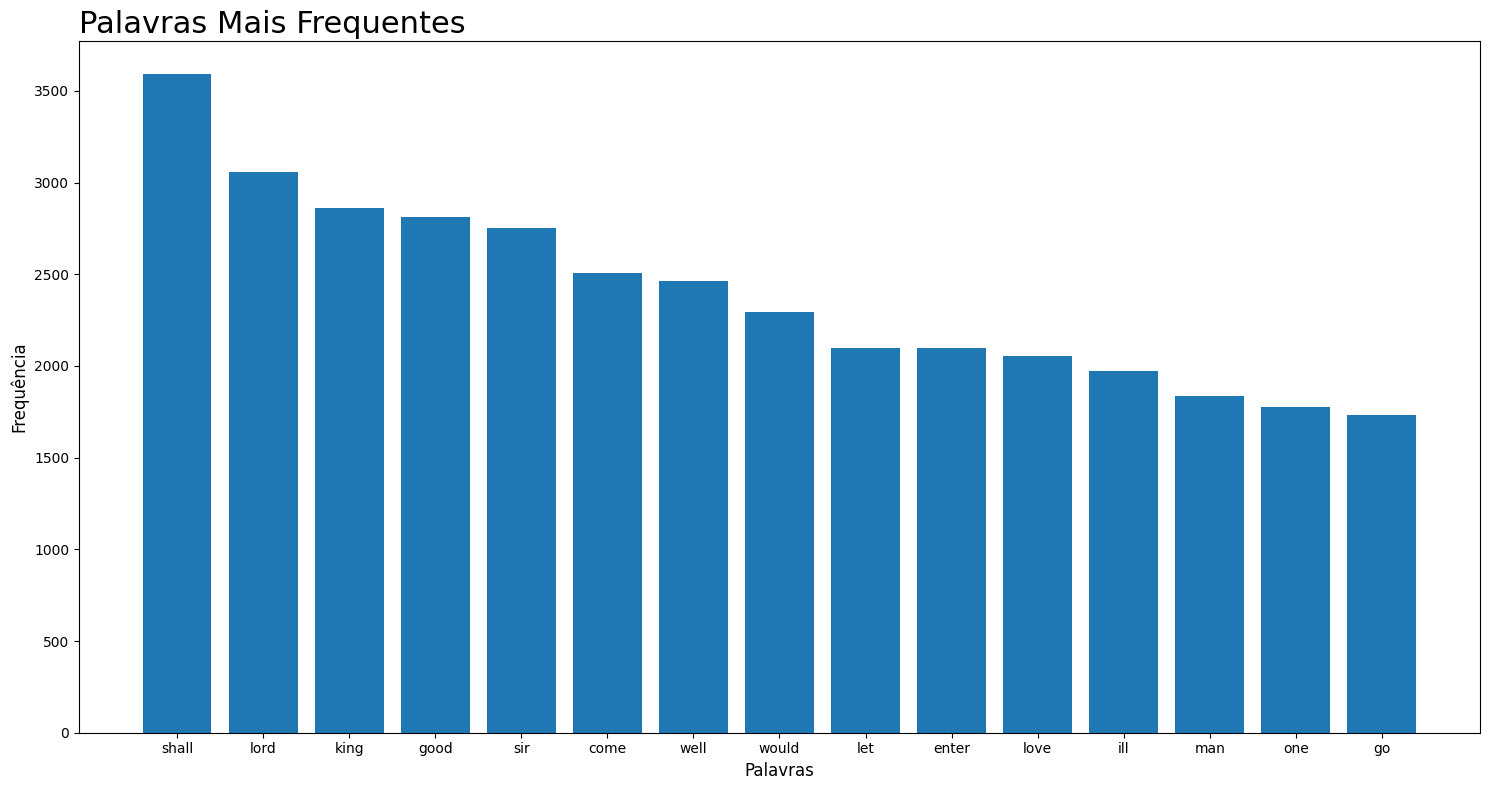

In [0]:
# Gráfico das palavras mais frequentes
palavras = list(dict_freq.keys())[:15]
frequencias = list(dict_freq.values())[:15]

plt.figure(figsize=(15, 8)) 
plt.bar(palavras, frequencias)

plt.xlabel('Palavras', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.title('Palavras Mais Frequentes', fontsize=22, loc='left')
plt.tight_layout()
plt.show()

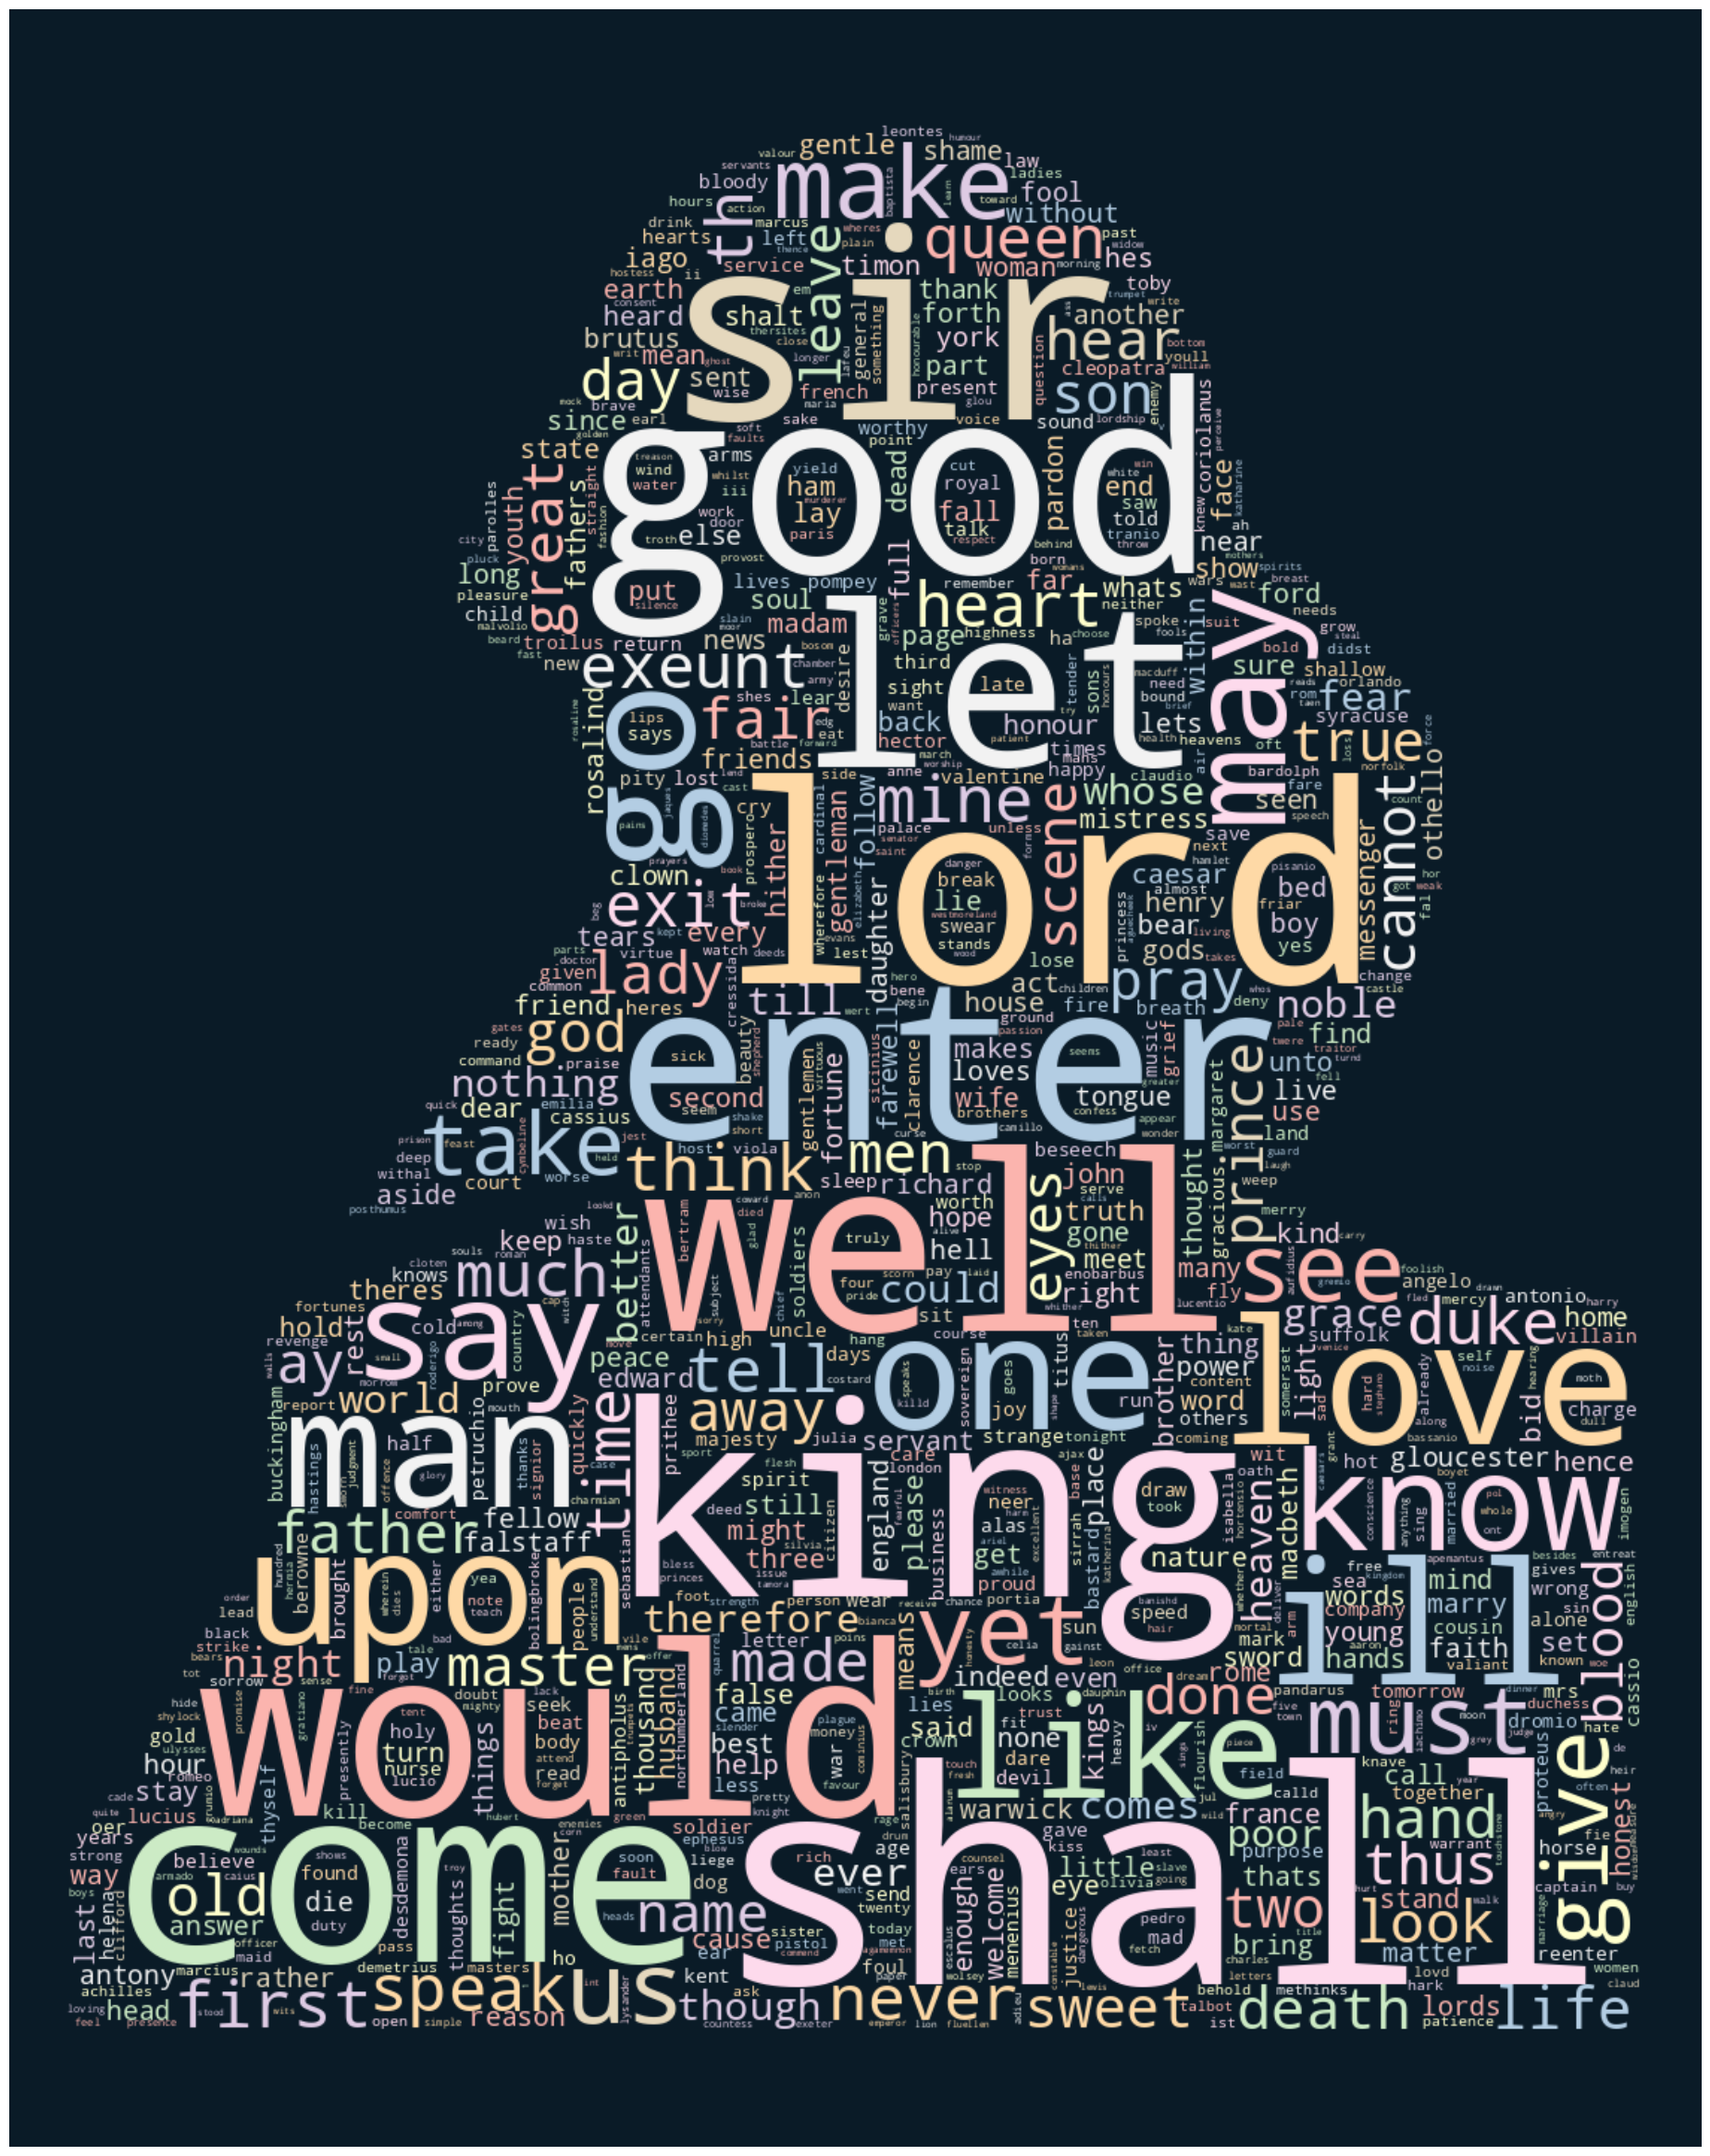

In [0]:
# Máscara para a nuvem de palavras (Droeshout portrait)
mask_image = np.array(Image.open("/Workspace/Shared/shakespeare.png"))

# Gerando a nuvem de palavras
wc = WordCloud(width=5670, height=7165, random_state=1, max_words=1000, max_font_size=200,
                      background_color='#0A1B27', mask=mask_image, contour_width=0, 
                      colormap='Pastel1', collocations=False).generate_from_frequencies(dict_freq)

plt.figure(figsize=(40, 30))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.savefig('wordcloud_shakespeare.png', dpi=300, bbox_inches='tight')
plt.show()